# Isotropic resampling for PanTS segmentation masks
 
### Resamples tumour + vessel masks to isotropic voxel spacing(positive cases only)
 
### Uses nearest-neighbor interpolation (order=0) since these are binary masks and linear/cubic interpolation would introduce non-binary values at edges.


In [2]:
import os
import numpy as np
import nibabel as nib
from scipy.ndimage import zoom
from pathlib import Path
from monai.transforms import LoadImage

In [5]:
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
from config import LABEL_DIR

veins_path = LABEL_DIR / "PanTS_00000086" / "segmentations" / "veins.nii.gz"
nii = nib.load(str(veins_path))
print("Voxel spacing (mm):", nii.header.get_zooms())

Voxel spacing (mm): (np.float32(0.701172), np.float32(0.701172), np.float32(2.5))


In [31]:
TARGET_SPACING = (0.70, 0.70, 0.70)

VASCULAR_MASKS = [
    "superior_mesenteric_artery.nii.gz",
    "celiac_artery.nii.gz",
    "veins.nii.gz",
    "postcava.nii.gz",
    "aorta.nii.gz",
]

TUMOUR_MASK_NAME = "pancreatic_lesion.nii.gz"

RESAMPLED_OUT_DIR = Path("../test_output/iso_resampled")


In [ ]:
def resample_to_isotropic(mask_path: Path, target_spacing=TARGET_SPACING, order=0):
    nii = nib.load(str(mask_path))
    data = nii.get_fdata()
    original_spacing = nii.header.get_zooms()[:3]

    data = (data > 0.5).astype(np.uint8)

    zoom_factors = [orig / target for orig, target in zip(original_spacing, target_spacing)]

    resampled = zoom(data, zoom_factors, order=order)
    resampled = (resampled > 0.5).astype(np.uint8)

    new_affine = nii.affine.copy()
    for i in range(3):
        new_affine[:3, i] = new_affine[:3, i] * (original_spacing[i] / target_spacing[i]) / zoom_factors[i] * zoom_factors[i]

    orig_affine = nii.affine
    scale_orig = np.array(original_spacing)
    scale_target = np.array(target_spacing)
    rotation = orig_affine[:3, :3] / scale_orig
    new_affine = np.eye(4)
    new_affine[:3, :3] = rotation * scale_target
    new_affine[:3, 3] = orig_affine[:3, 3]

    new_header = nii.header.copy()
    new_header.set_zooms(target_spacing)

    return resampled, new_affine, new_header


def process_case(case_id: str, label_dir: Path, out_dir: Path,
                  tumour_name=TUMOUR_MASK_NAME, vessel_names=VASCULAR_MASKS,
                  target_spacing=TARGET_SPACING):

    seg_dir = label_dir / case_id / "segmentations"
    out_seg_dir = out_dir / case_id / "segmentations"
    out_seg_dir.mkdir(parents=True, exist_ok=True)

    files_to_process = [tumour_name] + vessel_names

    for fname in files_to_process:
        src_path = seg_dir / fname
        if not src_path.exists():
            continue

        resampled, new_affine, new_header = resample_to_isotropic(src_path, target_spacing)

        out_path = out_seg_dir / fname
        nib.save(nib.Nifti1Image(resampled, new_affine, new_header), str(out_path))

    return out_seg_dir


In [23]:
# Total number of tumour-positive and tumour-negative cases

loader = LoadImage(image_only=True)

cases = sorted(os.listdir(LABEL_DIR))
lesion_counts = {}

for case in cases:
    lesion_path = f"{LABEL_DIR}/{case}/segmentations/pancreatic_lesion.nii.gz"
    if os.path.exists(lesion_path):
        data = loader(lesion_path).numpy()
        lesion_counts[case] = np.count_nonzero(data)

positive_cases = {k: v for k, v in lesion_counts.items() if v > 0}
print(f"Total cases: {len(cases)}")
print(f"Tumour-positive: {len(positive_cases)}")
print(f"Tumour-negative: {len(cases) - len(positive_cases)}")

Total cases: 9902
Tumour-positive: 1033
Tumour-negative: 8869


In [24]:
# Number of positive- and negative tumour-vessel mask overlap

contact_cases = []

for case in positive_cases:
    seg_path = f"{LABEL_DIR}/{case}/segmentations"
    lesion_bool = loader(f"{seg_path}/pancreatic_lesion.nii.gz").numpy() > 0

    for vessel in VASCULAR_MASKS:
        vessel_path = f"{seg_path}/{vessel}"
        if os.path.exists(vessel_path):
            vessel_data = loader(vessel_path).numpy() > 0
            if np.any(lesion_bool & vessel_data):
                contact_cases.append({"case": case, "vessel": vessel})
                break

print(f"Positive cases with tumour–vessel mask overlap: {len(contact_cases)}")
print(f"Positive cases without tumour–vessel mask overlap: {len(positive_cases) - len(contact_cases)}")

Positive cases with tumour–vessel mask overlap: 186
Positive cases without tumour–vessel mask overlap: 847


In [8]:
TEST_MODE = False
TEST_N = 2

case_ids = sorted(set(c["case"] for c in contact_cases))

if TEST_MODE:
    case_ids = case_ids[:TEST_N]
    print(f"[TEST MODE] Resampling {len(case_ids)} case(s) only: {case_ids}")
else:
    print(f"Resampling {len(case_ids)} contact cases to isotropic spacing {TARGET_SPACING} mm...")

for i, case_id in enumerate(case_ids, 1):
    try:
        out_seg_dir = process_case(case_id, LABEL_DIR, RESAMPLED_OUT_DIR)
        print(f"[{i}/{len(case_ids)}] OK: {case_id} -> {out_seg_dir}")
    except Exception as e:
        print(f"[{i}/{len(case_ids)}] FAIL: {case_id} -> {e}")

print("[DONE] Resampling complete.")

[TEST MODE] Resampling 2 case(s) only: ['PanTS_00000086', 'PanTS_00000167']
[1/2] OK: PanTS_00000086 -> test_output/iso_resampled/PanTS_00000086/segmentations
[2/2] OK: PanTS_00000167 -> test_output/iso_resampled/PanTS_00000167/segmentations
[DONE] Resampling complete.


## Visual sanity check: 
## compare original vs isotropically-resampled masks for one test case, to confirm alignment and shape are preserved.


In [36]:
check_case = case_ids[0]
check_path = RESAMPLED_OUT_DIR / check_case / "segmentations" / TUMOUR_MASK_NAME
if check_path.exists():
    check_nii = nib.load(str(check_path))
    print(f"\nVerification -- {check_case} tumour mask spacing after resampling:")
    print(check_nii.header.get_zooms())


Original spacing:  (np.float32(0.818359), np.float32(0.818359), np.float32(2.5))
Resampled spacing: (np.float32(0.7), np.float32(0.7), np.float32(0.7))
Original tumour voxel count:  1296
Resampled tumour voxel count: 6491
Original tumour shape:  (493, 282, 117)
Resampled tumour shape: (576, 330, 418)
Original tumour physical volume:  2169.9 mm^3
Resampled tumour physical volume: 2226.4 mm^3
Difference: 2.61%


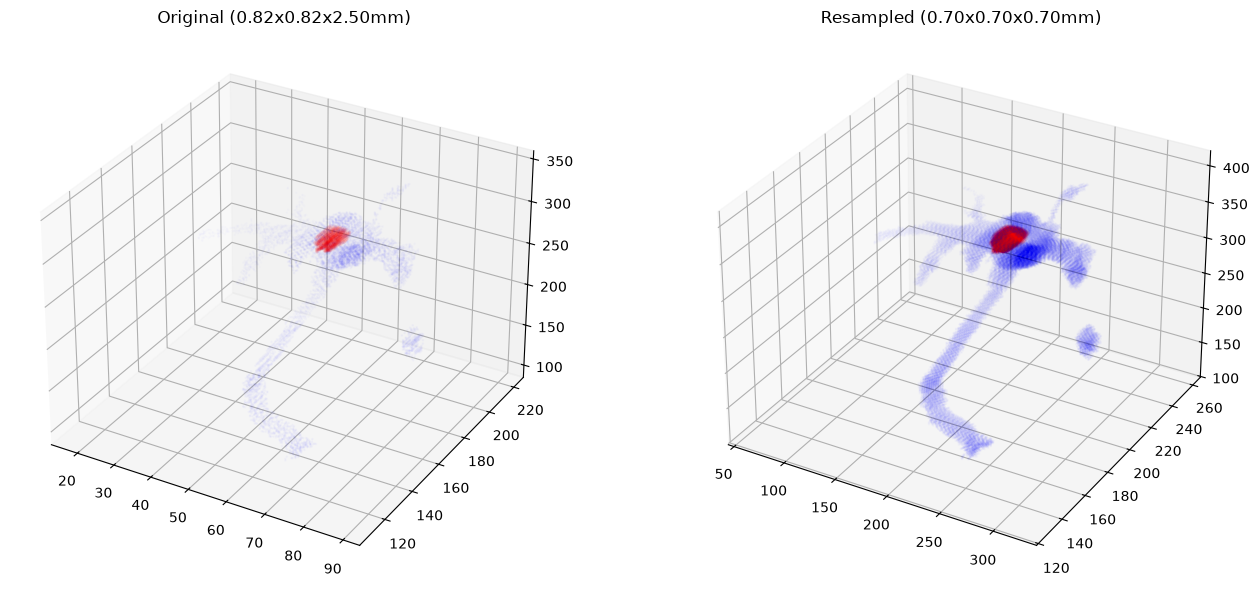

In [37]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path

CASE_ID = "PanTS_00000167"

ORIGINAL_TUMOUR = Path(f"{LABEL_DIR}/{CASE_ID}/segmentations/pancreatic_lesion.nii.gz")
RESAMPLED_TUMOUR = Path(f"test_output/iso_resampled/{CASE_ID}/segmentations/pancreatic_lesion.nii.gz")

ORIGINAL_VEINS = Path(f"{LABEL_DIR}/{CASE_ID}/segmentations/veins.nii.gz")
RESAMPLED_VEINS = Path(f"test_output/iso_resampled/{CASE_ID}/segmentations/veins.nii.gz")


def load_bin(path):
    nii = nib.load(str(path))
    return (nii.get_fdata() > 0.5).astype(np.uint8), nii.header.get_zooms()

orig_tumour, orig_spacing = load_bin(ORIGINAL_TUMOUR)
resamp_tumour, resamp_spacing = load_bin(RESAMPLED_TUMOUR)
orig_veins, _ = load_bin(ORIGINAL_VEINS)
resamp_veins, _ = load_bin(RESAMPLED_VEINS)

print(f"Original spacing:  {orig_spacing}")
print(f"Resampled spacing: {resamp_spacing}")
print(f"Original tumour voxel count:  {orig_tumour.sum()}")
print(f"Resampled tumour voxel count: {resamp_tumour.sum()}")
print(f"Original tumour shape:  {orig_tumour.shape}")
print(f"Resampled tumour shape: {resamp_tumour.shape}")

orig_volume_mm3 = orig_tumour.sum() * np.prod(orig_spacing)
resamp_volume_mm3 = resamp_tumour.sum() * np.prod(resamp_spacing)
print(f"Original tumour physical volume:  {orig_volume_mm3:.1f} mm^3")
print(f"Resampled tumour physical volume: {resamp_volume_mm3:.1f} mm^3")
print(f"Difference: {abs(orig_volume_mm3 - resamp_volume_mm3) / orig_volume_mm3 * 100:.2f}%")


def sparse_coords(mask, step=4):
    coords = np.argwhere(mask > 0)
    return coords[::step]

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
o_veins = sparse_coords(orig_veins, step=4)
o_tumour = sparse_coords(orig_tumour, step=2)
ax1.scatter(o_veins[:,2], o_veins[:,1], o_veins[:,0], c='blue', s=1, alpha=0.15)
ax1.scatter(o_tumour[:,2], o_tumour[:,1], o_tumour[:,0], c='red', s=3, alpha=0.3)
ax1.set_title(f"Original ({orig_spacing[0]:.2f}x{orig_spacing[1]:.2f}x{orig_spacing[2]:.2f}mm)")

ax2 = fig.add_subplot(122, projection='3d')
r_veins = sparse_coords(resamp_veins, step=4)
r_tumour = sparse_coords(resamp_tumour, step=2)
ax2.scatter(r_veins[:,2], r_veins[:,1], r_veins[:,0], c='blue', s=1, alpha=0.15)
ax2.scatter(r_tumour[:,2], r_tumour[:,1], r_tumour[:,0], c='red', s=3, alpha=0.3)
ax2.set_title(f"Resampled ({resamp_spacing[0]:.2f}x{resamp_spacing[1]:.2f}x{resamp_spacing[2]:.2f}mm)")

plt.tight_layout()
plt.show()

## Running resampling step on all 186 contact cases

In [18]:
TEST_MODE = False
TEST_N = 2

case_ids = sorted(set(c["case"] for c in contact_cases))

if TEST_MODE:
    case_ids = case_ids[:TEST_N]
    print(f"[TEST MODE] Resampling {len(case_ids)} case(s) only: {case_ids}")
else:
    print(f"Resampling {len(case_ids)} contact cases to isotropic spacing {TARGET_SPACING} mm...")

for i, case_id in enumerate(case_ids, 1):
    try:
        out_seg_dir = process_case(case_id, LABEL_DIR, RESAMPLED_OUT_DIR)
        print(f"[{i}/{len(case_ids)}] OK: {case_id} -> {out_seg_dir}")
    except Exception as e:
        print(f"[{i}/{len(case_ids)}] FAIL: {case_id} -> {e}")

print("[DONE] Resampling complete.")

Resampling 186 contact cases to isotropic spacing (0.7, 0.7, 0.7) mm...
[1/186] OK: PanTS_00000086 -> ../test_output/iso_resampled/PanTS_00000086/segmentations
[2/186] OK: PanTS_00000167 -> ../test_output/iso_resampled/PanTS_00000167/segmentations
[3/186] OK: PanTS_00000231 -> ../test_output/iso_resampled/PanTS_00000231/segmentations
[4/186] OK: PanTS_00000246 -> ../test_output/iso_resampled/PanTS_00000246/segmentations
[5/186] OK: PanTS_00000270 -> ../test_output/iso_resampled/PanTS_00000270/segmentations
[6/186] OK: PanTS_00000363 -> ../test_output/iso_resampled/PanTS_00000363/segmentations
[7/186] OK: PanTS_00000449 -> ../test_output/iso_resampled/PanTS_00000449/segmentations
[8/186] OK: PanTS_00000465 -> ../test_output/iso_resampled/PanTS_00000465/segmentations
[9/186] OK: PanTS_00000554 -> ../test_output/iso_resampled/PanTS_00000554/segmentations
[10/186] OK: PanTS_00000605 -> ../test_output/iso_resampled/PanTS_00000605/segmentations
[11/186] OK: PanTS_00000693 -> ../test_output/i

# NOTES:
### 22.07.26 : Resampling to isotropic spacing has to be done on all 1033 tumour-positive segmentation mask cases

In [45]:
loader = LoadImage(image_only=True)

cases = sorted([c for c in os.listdir(LABEL_DIR) if c.startswith("PanTS_")])
lesion_counts = {}

for case in cases:
    lesion_path = f"{LABEL_DIR}/{case}/segmentations/pancreatic_lesion.nii.gz"
    if os.path.exists(lesion_path):
        data = loader(lesion_path).numpy()
        lesion_counts[case] = np.count_nonzero(data)

mask_positive_cases = set(k for k, v in lesion_counts.items() if v > 0)

print(f"Mask-based tumour-positive: {len(mask_positive_cases)}")
assert len(mask_positive_cases) == 1033, f"Expected 1033, got {len(mask_positive_cases)}"

Mask-based tumour-positive: 1033


In [10]:
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
from config import ISO_RESAMPLING_DIR

RESAMPLED_OUT_DIR = ISO_RESAMPLING_DIR

case_ids = sorted(mask_positive_cases)
print(f"Resampling {len(case_ids)} cases (mask-based tumour-positive cohort) "
      f"to isotropic spacing {TARGET_SPACING} mm...")

TEST_MODE = False

if TEST_MODE:
    case_ids = case_ids[:2]
    print(f"[TEST MODE] Running on {len(case_ids)} case(s) only.")

failures = []

for i, case_id in enumerate(case_ids, 1):
    try:
        out_seg_dir = process_case(case_id, LABEL_DIR, RESAMPLED_OUT_DIR)
        if i % 50 == 0 or i == len(case_ids):
            print(f"[{i}/{len(case_ids)}] OK: {case_id}")
    except Exception as e:
        failures.append((case_id, str(e)))
        print(f"[{i}/{len(case_ids)}] FAIL: {case_id} -> {e}")

print(f"\n[DONE] Resampling complete. {len(case_ids) - len(failures)} succeeded, {len(failures)} failed.")

if failures:
    print("\nFailed cases:")
    for case_id, err in failures:
        print(f"  {case_id}: {err}")


Resampling 1033 cases (mask-based tumor-positive cohort) to isotropic spacing (0.7, 0.7, 0.7) mm...
[50/1033] OK: PanTS_00000488
[100/1033] OK: PanTS_00001077
[150/1033] OK: PanTS_00001541
[200/1033] OK: PanTS_00002028
[250/1033] OK: PanTS_00002498
[300/1033] OK: PanTS_00003033
[350/1033] OK: PanTS_00003441
[400/1033] OK: PanTS_00003921
[450/1033] OK: PanTS_00004454
[500/1033] OK: PanTS_00005085
[550/1033] OK: PanTS_00005742
[600/1033] OK: PanTS_00006282
[650/1033] OK: PanTS_00006837
[700/1033] OK: PanTS_00007227
[750/1033] OK: PanTS_00007615
[800/1033] OK: PanTS_00008086
[850/1033] OK: PanTS_00008658
[900/1033] OK: PanTS_00009119
[950/1033] OK: PanTS_00009375
[1000/1033] OK: PanTS_00009666
[1033/1033] OK: PanTS_00009901

[DONE] Resampling complete. 1033 succeeded, 0 failed.


## Check resampling process

Original spacing:  (np.float32(0.73046875), np.float32(0.73046875), np.float32(0.85363126))
Resampled spacing: (np.float32(0.7), np.float32(0.7), np.float32(0.7))
Original tumour voxel count:  1031
Resampled tumour voxel count: 1343
Original tumour shape:  (512, 449, 215)
Resampled tumour shape: (534, 469, 262)
Original tumour physical volume:  469.6 mm^3
Resampled tumour physical volume: 460.6 mm^3
Difference: 1.91%


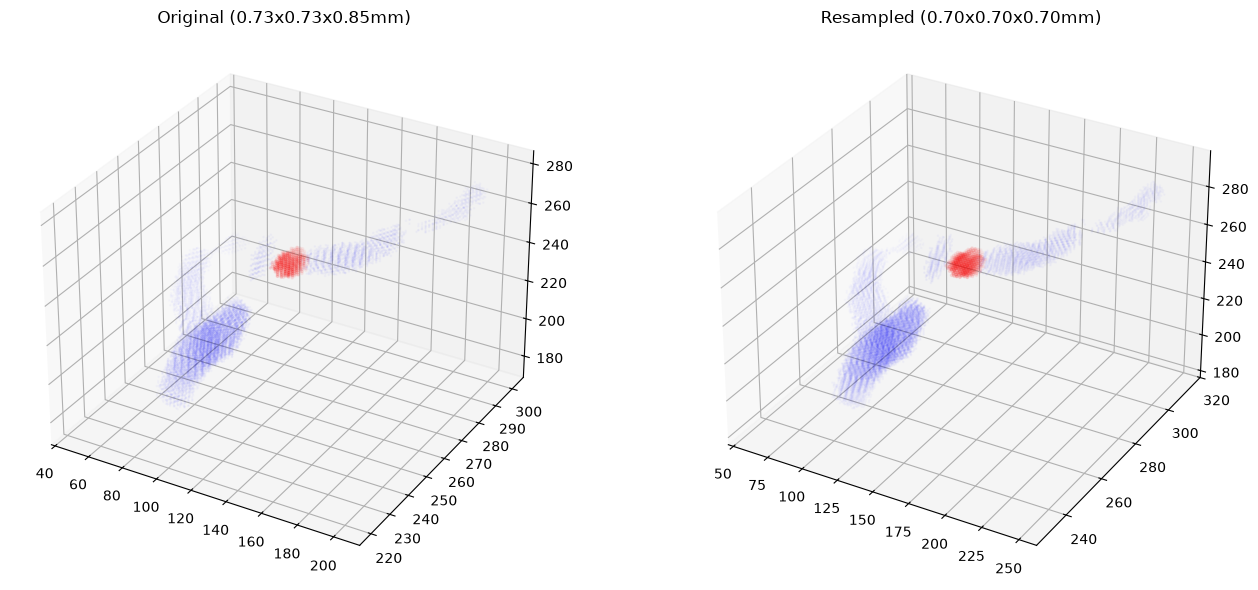

In [38]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path

CASE_ID = "PanTS_00006282"

ORIGINAL_TUMOUR = Path(f"{LABEL_DIR}/{CASE_ID}/segmentations/pancreatic_lesion.nii.gz")
RESAMPLED_TUMOUR = Path(f"{ISO_RESAMPLING_DIR}/{CASE_ID}/segmentations/pancreatic_lesion.nii.gz")

ORIGINAL_VEINS = Path(f"{LABEL_DIR}/{CASE_ID}/segmentations/veins.nii.gz")
RESAMPLED_VEINS = Path(f"{ISO_RESAMPLING_DIR}/{CASE_ID}/segmentations/veins.nii.gz")


def load_bin(path):
    nii = nib.load(str(path))
    return (nii.get_fdata() > 0.5).astype(np.uint8), nii.header.get_zooms()

orig_tumour, orig_spacing = load_bin(ORIGINAL_TUMOUR)
resamp_tumour, resamp_spacing = load_bin(RESAMPLED_TUMOUR)
orig_veins, _ = load_bin(ORIGINAL_VEINS)
resamp_veins, _ = load_bin(RESAMPLED_VEINS)

print(f"Original spacing:  {orig_spacing}")
print(f"Resampled spacing: {resamp_spacing}")
print(f"Original tumour voxel count:  {orig_tumour.sum()}")
print(f"Resampled tumour voxel count: {resamp_tumour.sum()}")
print(f"Original tumour shape:  {orig_tumour.shape}")
print(f"Resampled tumour shape: {resamp_tumour.shape}")

orig_volume_mm3 = orig_tumour.sum() * np.prod(orig_spacing)
resamp_volume_mm3 = resamp_tumour.sum() * np.prod(resamp_spacing)
print(f"Original tumour physical volume:  {orig_volume_mm3:.1f} mm^3")
print(f"Resampled tumour physical volume: {resamp_volume_mm3:.1f} mm^3")
print(f"Difference: {abs(orig_volume_mm3 - resamp_volume_mm3) / orig_volume_mm3 * 100:.2f}%")


def sparse_coords(mask, step=4):
    coords = np.argwhere(mask > 0)
    return coords[::step]

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
o_veins = sparse_coords(orig_veins, step=4)
o_tumour = sparse_coords(orig_tumour, step=2)
ax1.scatter(o_veins[:,2], o_veins[:,1], o_veins[:,0], c='blue', s=1, alpha=0.15)
ax1.scatter(o_tumour[:,2], o_tumour[:,1], o_tumour[:,0], c='red', s=3, alpha=0.3)
ax1.set_title(f"Original ({orig_spacing[0]:.2f}x{orig_spacing[1]:.2f}x{orig_spacing[2]:.2f}mm)")

ax2 = fig.add_subplot(122, projection='3d')
r_veins = sparse_coords(resamp_veins, step=4)
r_tumour = sparse_coords(resamp_tumour, step=2)
ax2.scatter(r_veins[:,2], r_veins[:,1], r_veins[:,0], c='blue', s=1, alpha=0.15)
ax2.scatter(r_tumour[:,2], r_tumour[:,1], r_tumour[:,0], c='red', s=3, alpha=0.3)
ax2.set_title(f"Resampled ({resamp_spacing[0]:.2f}x{resamp_spacing[1]:.2f}x{resamp_spacing[2]:.2f}mm)")

plt.tight_layout()
plt.show()

Original spacing:  (np.float32(0.8300781), np.float32(0.8300781), np.float32(3.0))
Resampled spacing: (np.float32(0.7), np.float32(0.7), np.float32(0.7))
Original tumour voxel count:  4437
Resampled tumour voxel count: 27203
Original tumour shape:  (461, 318, 156)
Resampled tumour shape: (547, 377, 669)
Original tumour physical volume:  9171.7 mm^3
Resampled tumour physical volume: 9330.6 mm^3
Difference: 1.73%


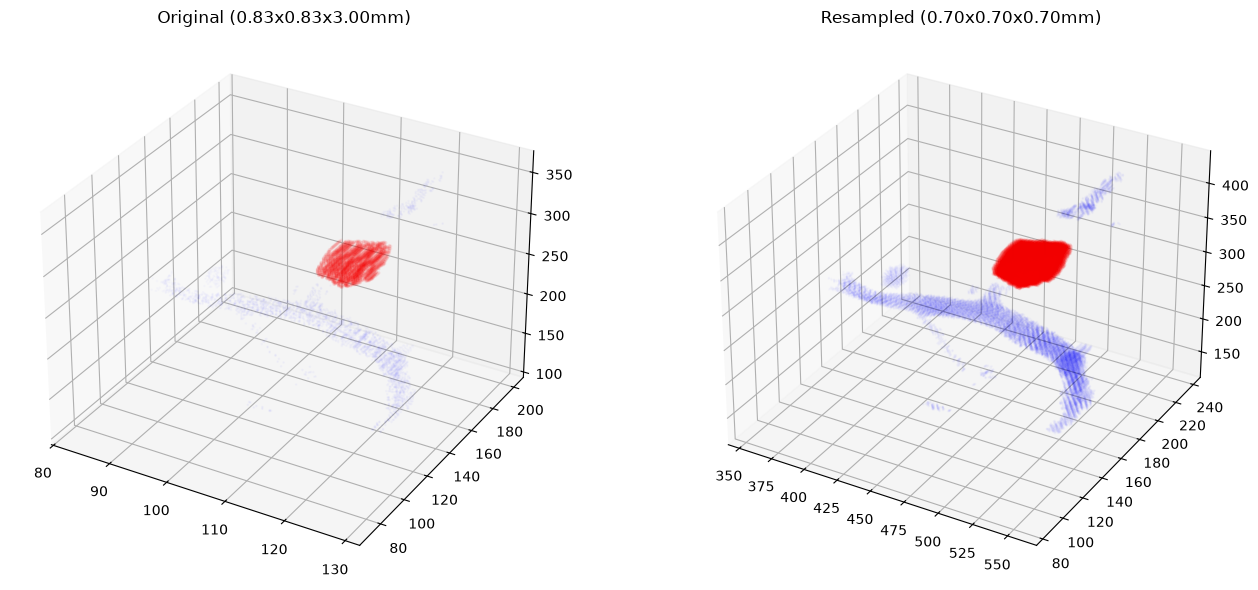

In [39]:
CASE_ID = "PanTS_00009901"

ORIGINAL_TUMOUR = Path(f"{LABEL_DIR}/{CASE_ID}/segmentations/pancreatic_lesion.nii.gz")
RESAMPLED_TUMOUR = Path(f"{ISO_RESAMPLING_DIR}/{CASE_ID}/segmentations/pancreatic_lesion.nii.gz")

ORIGINAL_VEINS = Path(f"{LABEL_DIR}/{CASE_ID}/segmentations/veins.nii.gz")
RESAMPLED_VEINS = Path(f"{ISO_RESAMPLING_DIR}/{CASE_ID}/segmentations/veins.nii.gz")


def load_bin(path):
    nii = nib.load(str(path))
    return (nii.get_fdata() > 0.5).astype(np.uint8), nii.header.get_zooms()

orig_tumour, orig_spacing = load_bin(ORIGINAL_TUMOUR)
resamp_tumour, resamp_spacing = load_bin(RESAMPLED_TUMOUR)
orig_veins, _ = load_bin(ORIGINAL_VEINS)
resamp_veins, _ = load_bin(RESAMPLED_VEINS)

print(f"Original spacing:  {orig_spacing}")
print(f"Resampled spacing: {resamp_spacing}")
print(f"Original tumour voxel count:  {orig_tumour.sum()}")
print(f"Resampled tumour voxel count: {resamp_tumour.sum()}")
print(f"Original tumour shape:  {orig_tumour.shape}")
print(f"Resampled tumour shape: {resamp_tumour.shape}")

orig_volume_mm3 = orig_tumour.sum() * np.prod(orig_spacing)
resamp_volume_mm3 = resamp_tumour.sum() * np.prod(resamp_spacing)
print(f"Original tumour physical volume:  {orig_volume_mm3:.1f} mm^3")
print(f"Resampled tumour physical volume: {resamp_volume_mm3:.1f} mm^3")
print(f"Difference: {abs(orig_volume_mm3 - resamp_volume_mm3) / orig_volume_mm3 * 100:.2f}%")


def sparse_coords(mask, step=4):
    coords = np.argwhere(mask > 0)
    return coords[::step]

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
o_veins = sparse_coords(orig_veins, step=4)
o_tumour = sparse_coords(orig_tumour, step=2)
ax1.scatter(o_veins[:,2], o_veins[:,1], o_veins[:,0], c='blue', s=1, alpha=0.15)
ax1.scatter(o_tumour[:,2], o_tumour[:,1], o_tumour[:,0], c='red', s=3, alpha=0.3)
ax1.set_title(f"Original ({orig_spacing[0]:.2f}x{orig_spacing[1]:.2f}x{orig_spacing[2]:.2f}mm)")

ax2 = fig.add_subplot(122, projection='3d')
r_veins = sparse_coords(resamp_veins, step=4)
r_tumour = sparse_coords(resamp_tumour, step=2)
ax2.scatter(r_veins[:,2], r_veins[:,1], r_veins[:,0], c='blue', s=1, alpha=0.15)
ax2.scatter(r_tumour[:,2], r_tumour[:,1], r_tumour[:,0], c='red', s=3, alpha=0.3)
ax2.set_title(f"Resampled ({resamp_spacing[0]:.2f}x{resamp_spacing[1]:.2f}x{resamp_spacing[2]:.2f}mm)")

plt.tight_layout()
plt.show()

Original spacing:  (np.float32(0.703125), np.float32(0.703125), np.float32(2.5))
Resampled spacing: (np.float32(0.7), np.float32(0.7), np.float32(0.7))
Original tumour voxel count:  6964
Resampled tumour voxel count: 26949
Original tumour shape:  (495, 322, 101)
Resampled tumour shape: (497, 323, 361)
Original tumour physical volume:  8607.2 mm^3
Resampled tumour physical volume: 9243.5 mm^3
Difference: 7.39%


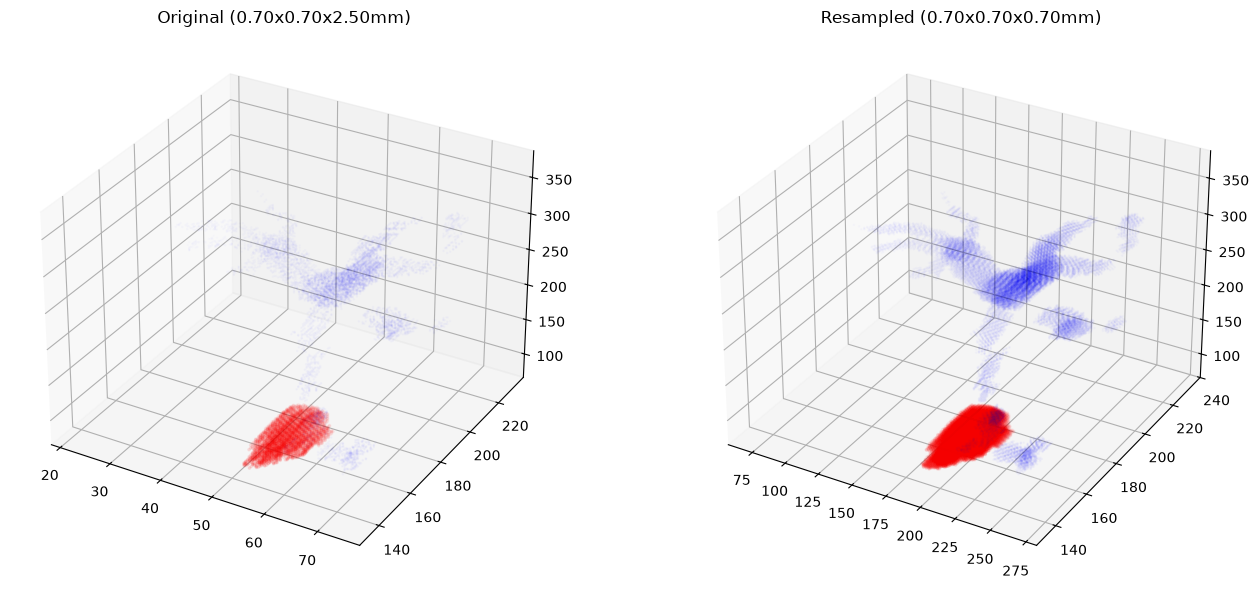

In [40]:
CASE_ID = "PanTS_00001541"

ORIGINAL_TUMOUR = Path(f"{LABEL_DIR}/{CASE_ID}/segmentations/pancreatic_lesion.nii.gz")
RESAMPLED_TUMOUR = Path(f"{ISO_RESAMPLING_DIR}/{CASE_ID}/segmentations/pancreatic_lesion.nii.gz")

ORIGINAL_VEINS = Path(f"{LABEL_DIR}/{CASE_ID}/segmentations/veins.nii.gz")
RESAMPLED_VEINS = Path(f"{ISO_RESAMPLING_DIR}/{CASE_ID}/segmentations/veins.nii.gz")


def load_bin(path):
    nii = nib.load(str(path))
    return (nii.get_fdata() > 0.5).astype(np.uint8), nii.header.get_zooms()

orig_tumour, orig_spacing = load_bin(ORIGINAL_TUMOUR)
resamp_tumour, resamp_spacing = load_bin(RESAMPLED_TUMOUR)
orig_veins, _ = load_bin(ORIGINAL_VEINS)
resamp_veins, _ = load_bin(RESAMPLED_VEINS)

print(f"Original spacing:  {orig_spacing}")
print(f"Resampled spacing: {resamp_spacing}")
print(f"Original tumour voxel count:  {orig_tumour.sum()}")
print(f"Resampled tumour voxel count: {resamp_tumour.sum()}")
print(f"Original tumour shape:  {orig_tumour.shape}")
print(f"Resampled tumour shape: {resamp_tumour.shape}")

orig_volume_mm3 = orig_tumour.sum() * np.prod(orig_spacing)
resamp_volume_mm3 = resamp_tumour.sum() * np.prod(resamp_spacing)
print(f"Original tumour physical volume:  {orig_volume_mm3:.1f} mm^3")
print(f"Resampled tumour physical volume: {resamp_volume_mm3:.1f} mm^3")
print(f"Difference: {abs(orig_volume_mm3 - resamp_volume_mm3) / orig_volume_mm3 * 100:.2f}%")


def sparse_coords(mask, step=4):
    coords = np.argwhere(mask > 0)
    return coords[::step]

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
o_veins = sparse_coords(orig_veins, step=4)
o_tumour = sparse_coords(orig_tumour, step=2)
ax1.scatter(o_veins[:,2], o_veins[:,1], o_veins[:,0], c='blue', s=1, alpha=0.15)
ax1.scatter(o_tumour[:,2], o_tumour[:,1], o_tumour[:,0], c='red', s=3, alpha=0.3)
ax1.set_title(f"Original ({orig_spacing[0]:.2f}x{orig_spacing[1]:.2f}x{orig_spacing[2]:.2f}mm)")

ax2 = fig.add_subplot(122, projection='3d')
r_veins = sparse_coords(resamp_veins, step=4)
r_tumour = sparse_coords(resamp_tumour, step=2)
ax2.scatter(r_veins[:,2], r_veins[:,1], r_veins[:,0], c='blue', s=1, alpha=0.15)
ax2.scatter(r_tumour[:,2], r_tumour[:,1], r_tumour[:,0], c='red', s=3, alpha=0.3)
ax2.set_title(f"Resampled ({resamp_spacing[0]:.2f}x{resamp_spacing[1]:.2f}x{resamp_spacing[2]:.2f}mm)")

plt.tight_layout()
plt.show()

Original spacing:  (np.float32(0.83203125), np.float32(0.83203125), np.float32(0.7))
Resampled spacing: (np.float32(0.7), np.float32(0.7), np.float32(0.7))
Original tumour voxel count:  2711
Resampled tumour voxel count: 3816
Original tumour shape:  (512, 460, 557)
Resampled tumour shape: (609, 547, 557)
Original tumour physical volume:  1313.7 mm^3
Resampled tumour physical volume: 1308.9 mm^3
Difference: 0.37%


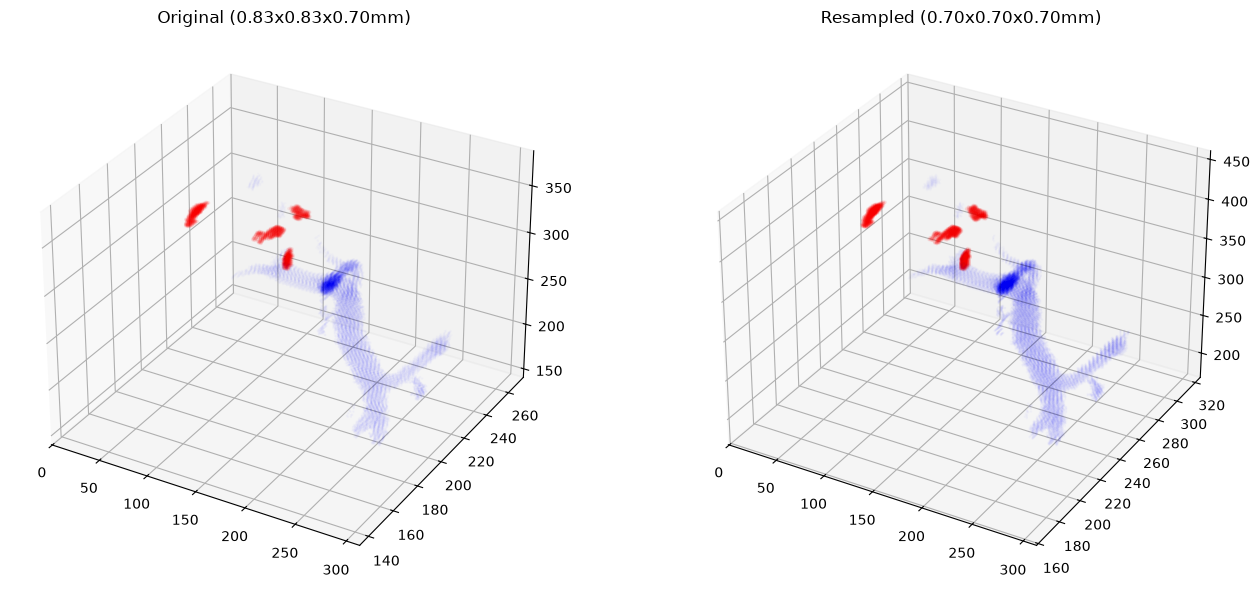

In [41]:
CASE_ID = "PanTS_00004454"

ORIGINAL_TUMOUR = Path(f"{LABEL_DIR}/{CASE_ID}/segmentations/pancreatic_lesion.nii.gz")
RESAMPLED_TUMOUR = Path(f"{ISO_RESAMPLING_DIR}/{CASE_ID}/segmentations/pancreatic_lesion.nii.gz")

ORIGINAL_VEINS = Path(f"{LABEL_DIR}/{CASE_ID}/segmentations/veins.nii.gz")
RESAMPLED_VEINS = Path(f"{ISO_RESAMPLING_DIR}/{CASE_ID}/segmentations/veins.nii.gz")


def load_bin(path):
    nii = nib.load(str(path))
    return (nii.get_fdata() > 0.5).astype(np.uint8), nii.header.get_zooms()

orig_tumour, orig_spacing = load_bin(ORIGINAL_TUMOUR)
resamp_tumour, resamp_spacing = load_bin(RESAMPLED_TUMOUR)
orig_veins, _ = load_bin(ORIGINAL_VEINS)
resamp_veins, _ = load_bin(RESAMPLED_VEINS)

print(f"Original spacing:  {orig_spacing}")
print(f"Resampled spacing: {resamp_spacing}")
print(f"Original tumour voxel count:  {orig_tumour.sum()}")
print(f"Resampled tumour voxel count: {resamp_tumour.sum()}")
print(f"Original tumour shape:  {orig_tumour.shape}")
print(f"Resampled tumour shape: {resamp_tumour.shape}")

orig_volume_mm3 = orig_tumour.sum() * np.prod(orig_spacing)
resamp_volume_mm3 = resamp_tumour.sum() * np.prod(resamp_spacing)
print(f"Original tumour physical volume:  {orig_volume_mm3:.1f} mm^3")
print(f"Resampled tumour physical volume: {resamp_volume_mm3:.1f} mm^3")
print(f"Difference: {abs(orig_volume_mm3 - resamp_volume_mm3) / orig_volume_mm3 * 100:.2f}%")


def sparse_coords(mask, step=4):
    coords = np.argwhere(mask > 0)
    return coords[::step]

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
o_veins = sparse_coords(orig_veins, step=4)
o_tumour = sparse_coords(orig_tumour, step=2)
ax1.scatter(o_veins[:,2], o_veins[:,1], o_veins[:,0], c='blue', s=1, alpha=0.15)
ax1.scatter(o_tumour[:,2], o_tumour[:,1], o_tumour[:,0], c='red', s=3, alpha=0.3)
ax1.set_title(f"Original ({orig_spacing[0]:.2f}x{orig_spacing[1]:.2f}x{orig_spacing[2]:.2f}mm)")

ax2 = fig.add_subplot(122, projection='3d')
r_veins = sparse_coords(resamp_veins, step=4)
r_tumour = sparse_coords(resamp_tumour, step=2)
ax2.scatter(r_veins[:,2], r_veins[:,1], r_veins[:,0], c='blue', s=1, alpha=0.15)
ax2.scatter(r_tumour[:,2], r_tumour[:,1], r_tumour[:,0], c='red', s=3, alpha=0.3)
ax2.set_title(f"Resampled ({resamp_spacing[0]:.2f}x{resamp_spacing[1]:.2f}x{resamp_spacing[2]:.2f}mm)")

plt.tight_layout()
plt.show()

Original spacing:  (np.float32(0.8574219), np.float32(0.8574219), np.float32(0.8013793))
Resampled spacing: (np.float32(0.7), np.float32(0.7), np.float32(0.7))
Original tumour voxel count:  2109
Resampled tumour voxel count: 3665
Original tumour shape:  (512, 424, 232)
Resampled tumour shape: (627, 519, 266)
Original tumour physical volume:  1242.5 mm^3
Resampled tumour physical volume: 1257.1 mm^3
Difference: 1.17%


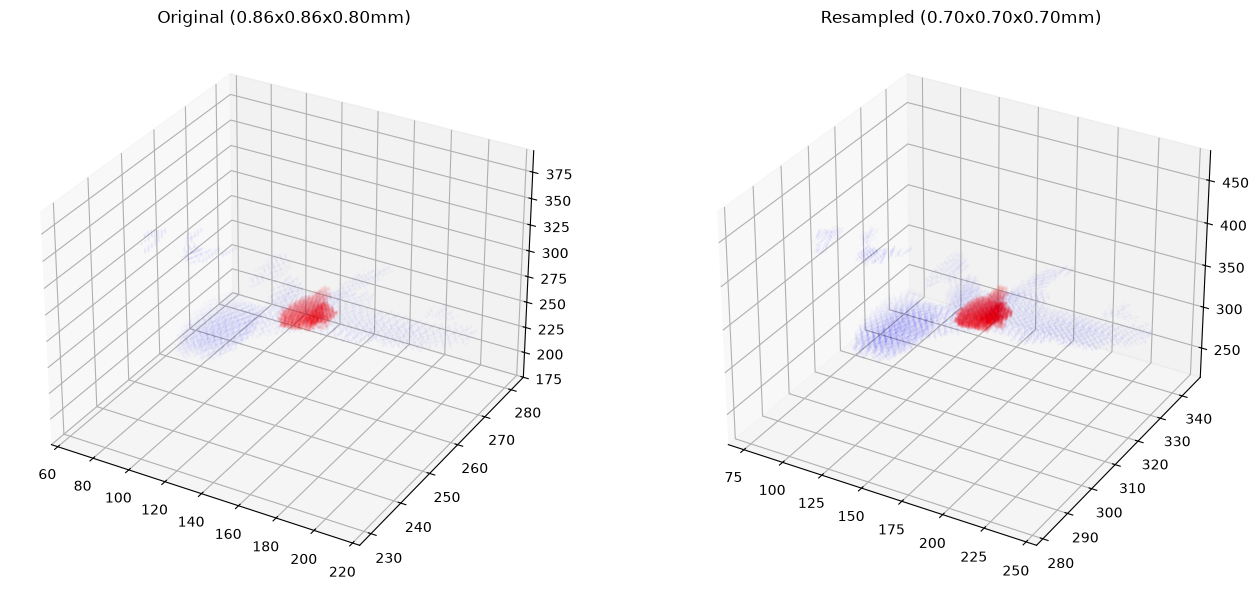

In [42]:
CASE_ID = "PanTS_00007227"

ORIGINAL_TUMOUR = Path(f"{LABEL_DIR}/{CASE_ID}/segmentations/pancreatic_lesion.nii.gz")
RESAMPLED_TUMOUR = Path(f"{ISO_RESAMPLING_DIR}/{CASE_ID}/segmentations/pancreatic_lesion.nii.gz")

ORIGINAL_VEINS = Path(f"{LABEL_DIR}/{CASE_ID}/segmentations/veins.nii.gz")
RESAMPLED_VEINS = Path(f"{ISO_RESAMPLING_DIR}/{CASE_ID}/segmentations/veins.nii.gz")


def load_bin(path):
    nii = nib.load(str(path))
    return (nii.get_fdata() > 0.5).astype(np.uint8), nii.header.get_zooms()

orig_tumour, orig_spacing = load_bin(ORIGINAL_TUMOUR)
resamp_tumour, resamp_spacing = load_bin(RESAMPLED_TUMOUR)
orig_veins, _ = load_bin(ORIGINAL_VEINS)
resamp_veins, _ = load_bin(RESAMPLED_VEINS)

print(f"Original spacing:  {orig_spacing}")
print(f"Resampled spacing: {resamp_spacing}")
print(f"Original tumour voxel count:  {orig_tumour.sum()}")
print(f"Resampled tumour voxel count: {resamp_tumour.sum()}")
print(f"Original tumour shape:  {orig_tumour.shape}")
print(f"Resampled tumour shape: {resamp_tumour.shape}")

orig_volume_mm3 = orig_tumour.sum() * np.prod(orig_spacing)
resamp_volume_mm3 = resamp_tumour.sum() * np.prod(resamp_spacing)
print(f"Original tumour physical volume:  {orig_volume_mm3:.1f} mm^3")
print(f"Resampled tumour physical volume: {resamp_volume_mm3:.1f} mm^3")
print(f"Difference: {abs(orig_volume_mm3 - resamp_volume_mm3) / orig_volume_mm3 * 100:.2f}%")


def sparse_coords(mask, step=4):
    coords = np.argwhere(mask > 0)
    return coords[::step]

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
o_veins = sparse_coords(orig_veins, step=4)
o_tumour = sparse_coords(orig_tumour, step=2)
ax1.scatter(o_veins[:,2], o_veins[:,1], o_veins[:,0], c='blue', s=1, alpha=0.15)
ax1.scatter(o_tumour[:,2], o_tumour[:,1], o_tumour[:,0], c='red', s=3, alpha=0.3)
ax1.set_title(f"Original ({orig_spacing[0]:.2f}x{orig_spacing[1]:.2f}x{orig_spacing[2]:.2f}mm)")

ax2 = fig.add_subplot(122, projection='3d')
r_veins = sparse_coords(resamp_veins, step=4)
r_tumour = sparse_coords(resamp_tumour, step=2)
ax2.scatter(r_veins[:,2], r_veins[:,1], r_veins[:,0], c='blue', s=1, alpha=0.15)
ax2.scatter(r_tumour[:,2], r_tumour[:,1], r_tumour[:,0], c='red', s=3, alpha=0.3)
ax2.set_title(f"Resampled ({resamp_spacing[0]:.2f}x{resamp_spacing[1]:.2f}x{resamp_spacing[2]:.2f}mm)")

plt.tight_layout()
plt.show()

Original spacing:  (np.float32(0.818359), np.float32(0.818359), np.float32(2.5))
Resampled spacing: (np.float32(0.7), np.float32(0.7), np.float32(0.7))
Original tumour voxel count:  1296
Resampled tumour voxel count: 6491
Original tumour shape:  (493, 282, 117)
Resampled tumour shape: (576, 330, 418)
Original tumour physical volume:  2169.9 mm^3
Resampled tumour physical volume: 2226.4 mm^3
Difference: 2.61%


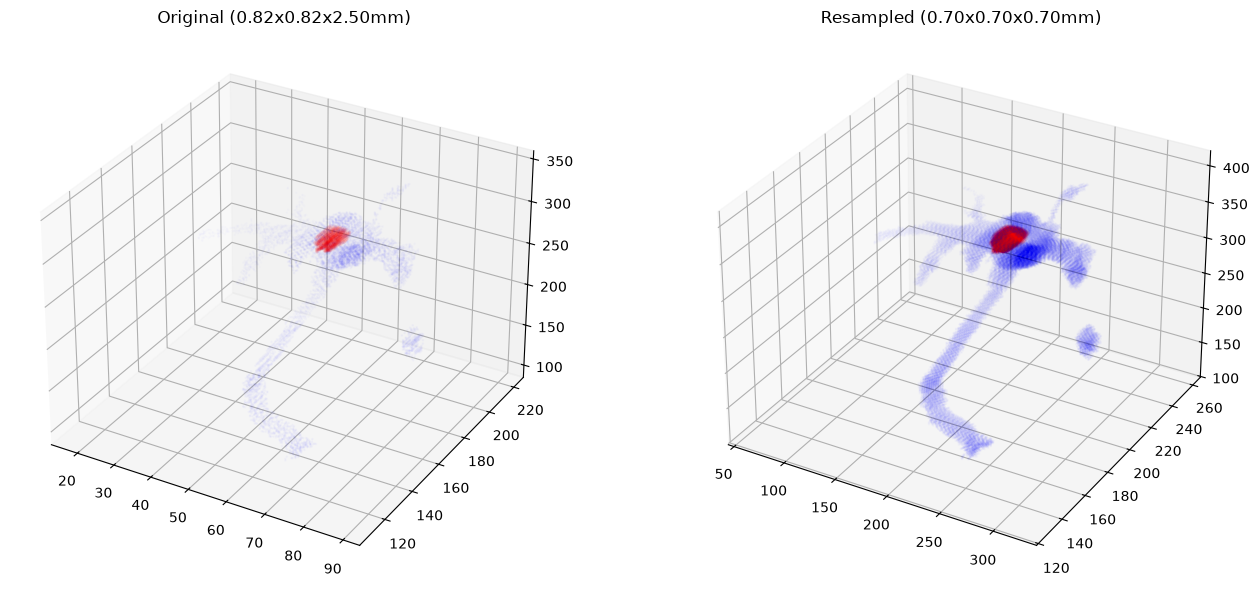

In [43]:
CASE_ID = "PanTS_00000167"

ORIGINAL_TUMOUR = Path(f"{LABEL_DIR}/{CASE_ID}/segmentations/pancreatic_lesion.nii.gz")
RESAMPLED_TUMOUR = Path(f"{ISO_RESAMPLING_DIR}/{CASE_ID}/segmentations/pancreatic_lesion.nii.gz")

ORIGINAL_VEINS = Path(f"{LABEL_DIR}/{CASE_ID}/segmentations/veins.nii.gz")
RESAMPLED_VEINS = Path(f"{ISO_RESAMPLING_DIR}/{CASE_ID}/segmentations/veins.nii.gz")


def load_bin(path):
    nii = nib.load(str(path))
    return (nii.get_fdata() > 0.5).astype(np.uint8), nii.header.get_zooms()

orig_tumour, orig_spacing = load_bin(ORIGINAL_TUMOUR)
resamp_tumour, resamp_spacing = load_bin(RESAMPLED_TUMOUR)
orig_veins, _ = load_bin(ORIGINAL_VEINS)
resamp_veins, _ = load_bin(RESAMPLED_VEINS)

print(f"Original spacing:  {orig_spacing}")
print(f"Resampled spacing: {resamp_spacing}")
print(f"Original tumour voxel count:  {orig_tumour.sum()}")
print(f"Resampled tumour voxel count: {resamp_tumour.sum()}")
print(f"Original tumour shape:  {orig_tumour.shape}")
print(f"Resampled tumour shape: {resamp_tumour.shape}")

orig_volume_mm3 = orig_tumour.sum() * np.prod(orig_spacing)
resamp_volume_mm3 = resamp_tumour.sum() * np.prod(resamp_spacing)
print(f"Original tumour physical volume:  {orig_volume_mm3:.1f} mm^3")
print(f"Resampled tumour physical volume: {resamp_volume_mm3:.1f} mm^3")
print(f"Difference: {abs(orig_volume_mm3 - resamp_volume_mm3) / orig_volume_mm3 * 100:.2f}%")


def sparse_coords(mask, step=4):
    coords = np.argwhere(mask > 0)
    return coords[::step]

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
o_veins = sparse_coords(orig_veins, step=4)
o_tumour = sparse_coords(orig_tumour, step=2)
ax1.scatter(o_veins[:,2], o_veins[:,1], o_veins[:,0], c='blue', s=1, alpha=0.15)
ax1.scatter(o_tumour[:,2], o_tumour[:,1], o_tumour[:,0], c='red', s=3, alpha=0.3)
ax1.set_title(f"Original ({orig_spacing[0]:.2f}x{orig_spacing[1]:.2f}x{orig_spacing[2]:.2f}mm)")

ax2 = fig.add_subplot(122, projection='3d')
r_veins = sparse_coords(resamp_veins, step=4)
r_tumour = sparse_coords(resamp_tumour, step=2)
ax2.scatter(r_veins[:,2], r_veins[:,1], r_veins[:,0], c='blue', s=1, alpha=0.15)
ax2.scatter(r_tumour[:,2], r_tumour[:,1], r_tumour[:,0], c='red', s=3, alpha=0.3)
ax2.set_title(f"Resampled ({resamp_spacing[0]:.2f}x{resamp_spacing[1]:.2f}x{resamp_spacing[2]:.2f}mm)")

plt.tight_layout()
plt.show()

Original spacing:  (np.float32(0.701172), np.float32(0.701172), np.float32(2.5))
Resampled spacing: (np.float32(0.7), np.float32(0.7), np.float32(0.7))
Original tumour voxel count:  6556
Resampled tumour voxel count: 24304
Original tumour shape:  (455, 371, 75)
Resampled tumour shape: (456, 372, 268)
Original tumour physical volume:  8058.0 mm^3
Resampled tumour physical volume: 8336.3 mm^3
Difference: 3.45%


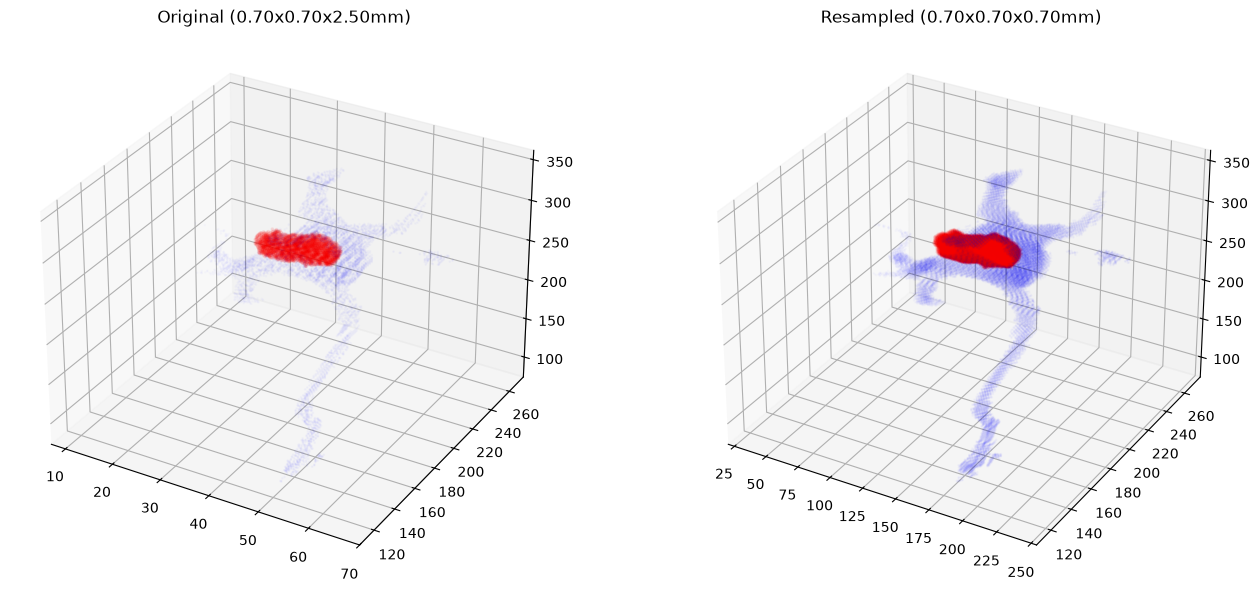

In [44]:
CASE_ID = "PanTS_00000086"

ORIGINAL_TUMOUR = Path(f"{LABEL_DIR}/{CASE_ID}/segmentations/pancreatic_lesion.nii.gz")
RESAMPLED_TUMOUR = Path(f"{ISO_RESAMPLING_DIR}/{CASE_ID}/segmentations/pancreatic_lesion.nii.gz")

ORIGINAL_VEINS = Path(f"{LABEL_DIR}/{CASE_ID}/segmentations/veins.nii.gz")
RESAMPLED_VEINS = Path(f"{ISO_RESAMPLING_DIR}/{CASE_ID}/segmentations/veins.nii.gz")


def load_bin(path):
    nii = nib.load(str(path))
    return (nii.get_fdata() > 0.5).astype(np.uint8), nii.header.get_zooms()

orig_tumour, orig_spacing = load_bin(ORIGINAL_TUMOUR)
resamp_tumour, resamp_spacing = load_bin(RESAMPLED_TUMOUR)
orig_veins, _ = load_bin(ORIGINAL_VEINS)
resamp_veins, _ = load_bin(RESAMPLED_VEINS)

print(f"Original spacing:  {orig_spacing}")
print(f"Resampled spacing: {resamp_spacing}")
print(f"Original tumour voxel count:  {orig_tumour.sum()}")
print(f"Resampled tumour voxel count: {resamp_tumour.sum()}")
print(f"Original tumour shape:  {orig_tumour.shape}")
print(f"Resampled tumour shape: {resamp_tumour.shape}")

orig_volume_mm3 = orig_tumour.sum() * np.prod(orig_spacing)
resamp_volume_mm3 = resamp_tumour.sum() * np.prod(resamp_spacing)
print(f"Original tumour physical volume:  {orig_volume_mm3:.1f} mm^3")
print(f"Resampled tumour physical volume: {resamp_volume_mm3:.1f} mm^3")
print(f"Difference: {abs(orig_volume_mm3 - resamp_volume_mm3) / orig_volume_mm3 * 100:.2f}%")


def sparse_coords(mask, step=4):
    coords = np.argwhere(mask > 0)
    return coords[::step]

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
o_veins = sparse_coords(orig_veins, step=4)
o_tumour = sparse_coords(orig_tumour, step=2)
ax1.scatter(o_veins[:,2], o_veins[:,1], o_veins[:,0], c='blue', s=1, alpha=0.15)
ax1.scatter(o_tumour[:,2], o_tumour[:,1], o_tumour[:,0], c='red', s=3, alpha=0.3)
ax1.set_title(f"Original ({orig_spacing[0]:.2f}x{orig_spacing[1]:.2f}x{orig_spacing[2]:.2f}mm)")

ax2 = fig.add_subplot(122, projection='3d')
r_veins = sparse_coords(resamp_veins, step=4)
r_tumour = sparse_coords(resamp_tumour, step=2)
ax2.scatter(r_veins[:,2], r_veins[:,1], r_veins[:,0], c='blue', s=1, alpha=0.15)
ax2.scatter(r_tumour[:,2], r_tumour[:,1], r_tumour[:,0], c='red', s=3, alpha=0.3)
ax2.set_title(f"Resampled ({resamp_spacing[0]:.2f}x{resamp_spacing[1]:.2f}x{resamp_spacing[2]:.2f}mm)")

plt.tight_layout()
plt.show()

## Batch QA check
Compare tumour mask physical volume before vs. after isotropic resampling, across the full 1033-case cohort. It flags any case above a volume-difference tolerance for manual review.

In [ ]:
import numpy as np
import nibabel as nib
from pathlib import Path

from config import LABEL_DIR, ISO_RESAMPLING_DIR

TUMOUR_MASK_NAME = "pancreatic_lesion.nii.gz"
VOLUME_DIFF_TOLERANCE_PCT = 5.0


def load_bin_with_spacing(path: Path):
    nii = nib.load(str(path))
    data = (nii.get_fdata() > 0.5).astype(np.uint8)
    spacing = nii.header.get_zooms()[:3]
    return data, spacing


def check_case_volume(case_id: str):
    orig_path = LABEL_DIR / case_id / "segmentations" / TUMOUR_MASK_NAME
    resamp_path = ISO_RESAMPLING_DIR / case_id / "segmentations" / TUMOUR_MASK_NAME

    if not orig_path.exists() or not resamp_path.exists():
        return None

    orig_data, orig_spacing = load_bin_with_spacing(orig_path)
    resamp_data, resamp_spacing = load_bin_with_spacing(resamp_path)

    orig_volume = orig_data.sum() * np.prod(orig_spacing)
    resamp_volume = resamp_data.sum() * np.prod(resamp_spacing)

    if orig_volume == 0:
        return None

    pct_diff = abs(orig_volume - resamp_volume) / orig_volume * 100
    return {
        "case_id": case_id,
        "orig_volume_mm3": float(orig_volume),
        "resamp_volume_mm3": float(resamp_volume),
        "pct_diff": float(pct_diff),
    }



case_ids = sorted(mask_positive_cases)

results = []
missing = []

for i, case_id in enumerate(case_ids, 1):
    r = check_case_volume(case_id)
    if r is None:
        missing.append(case_id)
    else:
        results.append(r)
    if i % 100 == 0 or i == len(case_ids):
        print(f"[{i}/{len(case_ids)}] checked...")

print(f"\n[DONE] Checked {len(results)} cases, {len(missing)} missing/skipped.")

if missing:
    print(f"Missing/skipped case IDs: {missing[:20]}{' ...' if len(missing) > 20 else ''}")


pct_diffs = np.array([r["pct_diff"] for r in results])

print(f"\nVolume difference stats across {len(results)} cases:")
print(f"  mean:   {pct_diffs.mean():.2f}%")
print(f"  median: {np.median(pct_diffs):.2f}%")
print(f"  max:    {pct_diffs.max():.2f}%")
print(f"  min:    {pct_diffs.min():.2f}%")


outliers = [r for r in results if r["pct_diff"] > VOLUME_DIFF_TOLERANCE_PCT]
outliers.sort(key=lambda r: -r["pct_diff"])

print(f"\nCases exceeding {VOLUME_DIFF_TOLERANCE_PCT}% volume difference: {len(outliers)}")
for r in outliers[:30]:
    print(f"  {r['case_id']}: {r['pct_diff']:.2f}% "
          f"(orig={r['orig_volume_mm3']:.1f}mm^3, resampled={r['resamp_volume_mm3']:.1f}mm^3)")


import csv
out_csv = Path("outputs/resampling_volume_check.csv")
out_csv.parent.mkdir(parents=True, exist_ok=True)

with open(out_csv, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["case_id", "orig_volume_mm3", "resamp_volume_mm3", "pct_diff"])
    writer.writeheader()
    writer.writerows(results)

print(f"\nFull results saved to {out_csv}")

[100/1033] checked...
[200/1033] checked...
[300/1033] checked...
[400/1033] checked...
[500/1033] checked...
[600/1033] checked...
[700/1033] checked...
[800/1033] checked...
[900/1033] checked...
[1000/1033] checked...
[1033/1033] checked...

[DONE] Checked 1033 cases, 0 missing/skipped.

Volume difference stats across 1033 cases:
  mean:   1.99%
  median: 1.17%
  max:    56.99%
  min:    0.00%

Cases exceeding 5.0% volume difference: 93
  PanTS_00007947: 56.99% (orig=12.0mm^3, resampled=5.1mm^3)
  PanTS_00000044: 22.16% (orig=7.1mm^3, resampled=5.5mm^3)
  PanTS_00005043: 22.16% (orig=1.8mm^3, resampled=1.4mm^3)
  PanTS_00003059: 19.95% (orig=5.6mm^3, resampled=4.5mm^3)
  PanTS_00006811: 16.12% (orig=41.1mm^3, resampled=47.7mm^3)
  PanTS_00009027: 15.85% (orig=181.2mm^3, resampled=209.9mm^3)
  PanTS_00005854: 15.46% (orig=45.2mm^3, resampled=52.1mm^3)
  PanTS_00006854: 14.98% (orig=41.2mm^3, resampled=35.0mm^3)
  PanTS_00004366: 13.03% (orig=303.8mm^3, resampled=343.3mm^3)
  PanTS_00

## NOTES:
93 of 1033 cases (9.0%) exceeded a 5% volume difference following isotropic resampling. Manual inspection of the largest discrepancies revealed these predominantly affected very small tumour masks (often <15mm³), where binarisation following interpolation is disproportionately sensitive to boundary voxel changes. 
Absolute volume differences for these cases remained small (typically <10mm³) and their impact on downstream vessel-contact analysis is expected to be minimal given the limited spatial extent of these lesions.

# Distance-based contact check
Distance-based tumour-vessel proximity check, run on isotropically resampled masks.

In [ ]:
import numpy as np
import nibabel as nib
from pathlib import Path
from scipy.ndimage import distance_transform_edt

from config import LABEL_DIR, ISO_RESAMPLING_DIR

VASCULAR_MASKS = [
    "superior_mesenteric_artery.nii.gz",
    "celiac_artery.nii.gz",
    "veins.nii.gz",
    "postcava.nii.gz",
    "aorta.nii.gz",
]

TUMOUR_MASK_NAME = "pancreatic_lesion.nii.gz"

CONTACT_DISTANCE_THRESHOLD_MM = 2.0


def load_bin(path: Path):
    nii = nib.load(str(path))
    data = (nii.get_fdata() > 0.5).astype(np.uint8)
    spacing = nii.header.get_zooms()[:3]
    return data, spacing


def min_distance_mm(tumour_mask: np.ndarray, vessel_mask: np.ndarray, spacing):
    if tumour_mask.sum() == 0 or vessel_mask.sum() == 0:
        return None

    if np.any(np.logical_and(tumour_mask, vessel_mask)):
        return 0.0


    dist_to_vessel = distance_transform_edt(~vessel_mask.astype(bool), sampling=spacing)

    tumour_coords = np.where(tumour_mask > 0)
    min_dist = dist_to_vessel[tumour_coords].min()

    return float(min_dist)


def check_case_contact(case_id: str, use_resampled=True):
    base_dir = ISO_RESAMPLING_DIR if use_resampled else LABEL_DIR
    seg_dir = base_dir / case_id / "segmentations"

    tumour_path = seg_dir / TUMOUR_MASK_NAME
    if not tumour_path.exists():
        return None

    tumour_mask, spacing = load_bin(tumour_path)
    if tumour_mask.sum() == 0:
        return None

    distances = {}
    for vessel_fname in VASCULAR_MASKS:
        vessel_path = seg_dir / vessel_fname
        if not vessel_path.exists():
            continue
        vessel_mask, _ = load_bin(vessel_path)
        d = min_distance_mm(tumour_mask, vessel_mask, spacing)
        if d is not None:
            distances[vessel_fname.replace(".nii.gz", "")] = d

    return distances



case_ids = sorted(mask_positive_cases)

results = {}
failures = []

for i, case_id in enumerate(case_ids, 1):
    try:
        distances = check_case_contact(case_id, use_resampled=True)
        if distances is not None:
            results[case_id] = distances
    except Exception as e:
        failures.append((case_id, str(e)))
    if i % 100 == 0 or i == len(case_ids):
        print(f"[{i}/{len(case_ids)}] checked...")

print(f"\n[DONE] Checked {len(results)} cases, {len(failures)} failed.")
if failures:
    print("Failures:", failures[:10])

# ------------------------- classify contact vs no-contact -------------------------

new_contact_cases = []
new_no_contact_cases = []

for case_id, distances in results.items():
    if not distances:
        new_no_contact_cases.append(case_id)
        continue
    min_overall_distance = min(distances.values())
    if min_overall_distance <= CONTACT_DISTANCE_THRESHOLD_MM:
        new_contact_cases.append(case_id)
    else:
        new_no_contact_cases.append(case_id)

print(f"\nUsing {CONTACT_DISTANCE_THRESHOLD_MM}mm distance threshold:")
print(f"  Contact cases:    {len(new_contact_cases)}")
print(f"  No-contact cases: {len(new_no_contact_cases)}")

# ------------------------- compare against original strict-overlap split -------------------------

original_contact_case_ids = set(c["case"] for c in contact_cases)
new_contact_case_ids = set(new_contact_cases)

newly_found_contact = new_contact_case_ids - original_contact_case_ids
no_longer_contact = original_contact_case_ids - new_contact_case_ids

print(f"\n--- Comparison against original strict-overlap check ---")
print(f"Original contact cases: {len(original_contact_case_ids)}")
print(f"New (distance-based) contact cases: {len(new_contact_case_ids)}")
print(f"Newly identified as contact (missed by original check): {len(newly_found_contact)}")
print(f"No longer classified as contact: {len(no_longer_contact)}")

if newly_found_contact:
    print(f"\nExample newly-found contact cases: {list(newly_found_contact)[:10]}")


import json
out_path = Path("outputs/vessel_distances.json")
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, "w") as f:
    json.dump(results, f, indent=2)

print(f"\nResults: {out_path}")

[100/1033] checked...
[200/1033] checked...
[300/1033] checked...
[400/1033] checked...
[500/1033] checked...
[600/1033] checked...
[700/1033] checked...
[800/1033] checked...
[900/1033] checked...
[1000/1033] checked...
[1033/1033] checked...

[DONE] Checked 1033 cases, 0 failed.

Using 2.0mm distance threshold:
  Contact cases:    728
  No-contact cases: 305


NameError: name 'contact_cases' is not defined

In [25]:
print(len(results))

1033


In [26]:
# ------------------------- classify contact vs no-contact -------------------------

new_contact_cases = []
new_no_contact_cases = []

for case_id, distances in results.items():
    if not distances:
        new_no_contact_cases.append(case_id)
        continue
    min_overall_distance = min(distances.values())
    if min_overall_distance <= CONTACT_DISTANCE_THRESHOLD_MM:
        new_contact_cases.append(case_id)
    else:
        new_no_contact_cases.append(case_id)

print(f"\nUsing {CONTACT_DISTANCE_THRESHOLD_MM}mm distance threshold:")
print(f"  Contact cases:    {len(new_contact_cases)}")
print(f"  No-contact cases: {len(new_no_contact_cases)}")

# ------------------------- compare against original strict-overlap split -------------------------

original_contact_case_ids = set(c["case"] for c in contact_cases)
new_contact_case_ids = set(new_contact_cases)

newly_found_contact = new_contact_case_ids - original_contact_case_ids
no_longer_contact = original_contact_case_ids - new_contact_case_ids

print(f"\n--- Comparison against original strict-overlap check ---")
print(f"Original contact cases: {len(original_contact_case_ids)}")
print(f"New (distance-based) contact cases: {len(new_contact_case_ids)}")
print(f"Newly identified as contact (missed by original check): {len(newly_found_contact)}")
print(f"No longer classified as contact: {len(no_longer_contact)}")

if newly_found_contact:
    print(f"\nExample newly-found contact cases: {list(newly_found_contact)[:10]}")


import json
out_path = Path("outputs/vessel_distances.json")
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, "w") as f:
    json.dump(results, f, indent=2)

print(f"\nResults: {out_path}")


Using 2.0mm distance threshold:
  Contact cases:    728
  No-contact cases: 305

--- Comparison against original strict-overlap check ---
Original contact cases: 186
New (distance-based) contact cases: 728
Newly identified as contact (missed by original check): 542
No longer classified as contact: 0

Example newly-found contact cases: ['PanTS_00009385', 'PanTS_00007890', 'PanTS_00000932', 'PanTS_00004226', 'PanTS_00002123', 'PanTS_00003128', 'PanTS_00004231', 'PanTS_00008086', 'PanTS_00006193', 'PanTS_00004669']

Full per-vessel distance results saved to outputs/vessel_distances.json


## During the test of the pipeline, one case showed 2 distinct lesions on the graph. This check is to see if it appears in more cases

In [32]:
from scipy.ndimage import label

labeled, n_components = label(TUMOUR_MASK_NAME)
print(f"Number of separate tumour components: {n_components}")

Number of separate tumour components: 1


In [33]:
import nibabel as nib
from scipy.ndimage import label

multi_lesion_cases = []
for case_id in mask_positive_cases:
    tumour_path = ISO_RESAMPLING_DIR / case_id / "segmentations" / "pancreatic_lesion.nii.gz"
    tumour_mask = (nib.load(str(tumour_path)).get_fdata() > 0.5).astype(np.uint8)
    _, n_components = label(tumour_mask)
    if n_components > 1:
        multi_lesion_cases.append((case_id, n_components))

print(f"Cases with >1 tumour component: {len(multi_lesion_cases)}")

Cases with >1 tumour component: 182


# NOTES:
- 182 of all positive cases have disconnected tumour lesions. This need to be addressed.